In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [23]:
df = pd.read_json("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/test_case_H28/results/zone9_21.json")
df_0 = pd.read_json("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/test_case_H28/results/zone0_21.json")
df_9 = pd.read_json("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/test_case_H28/results/zone9_heatingattern.json")

In [32]:
fd = pd.read_json("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/test_case_H28/results/zone9_degree_increments.json")

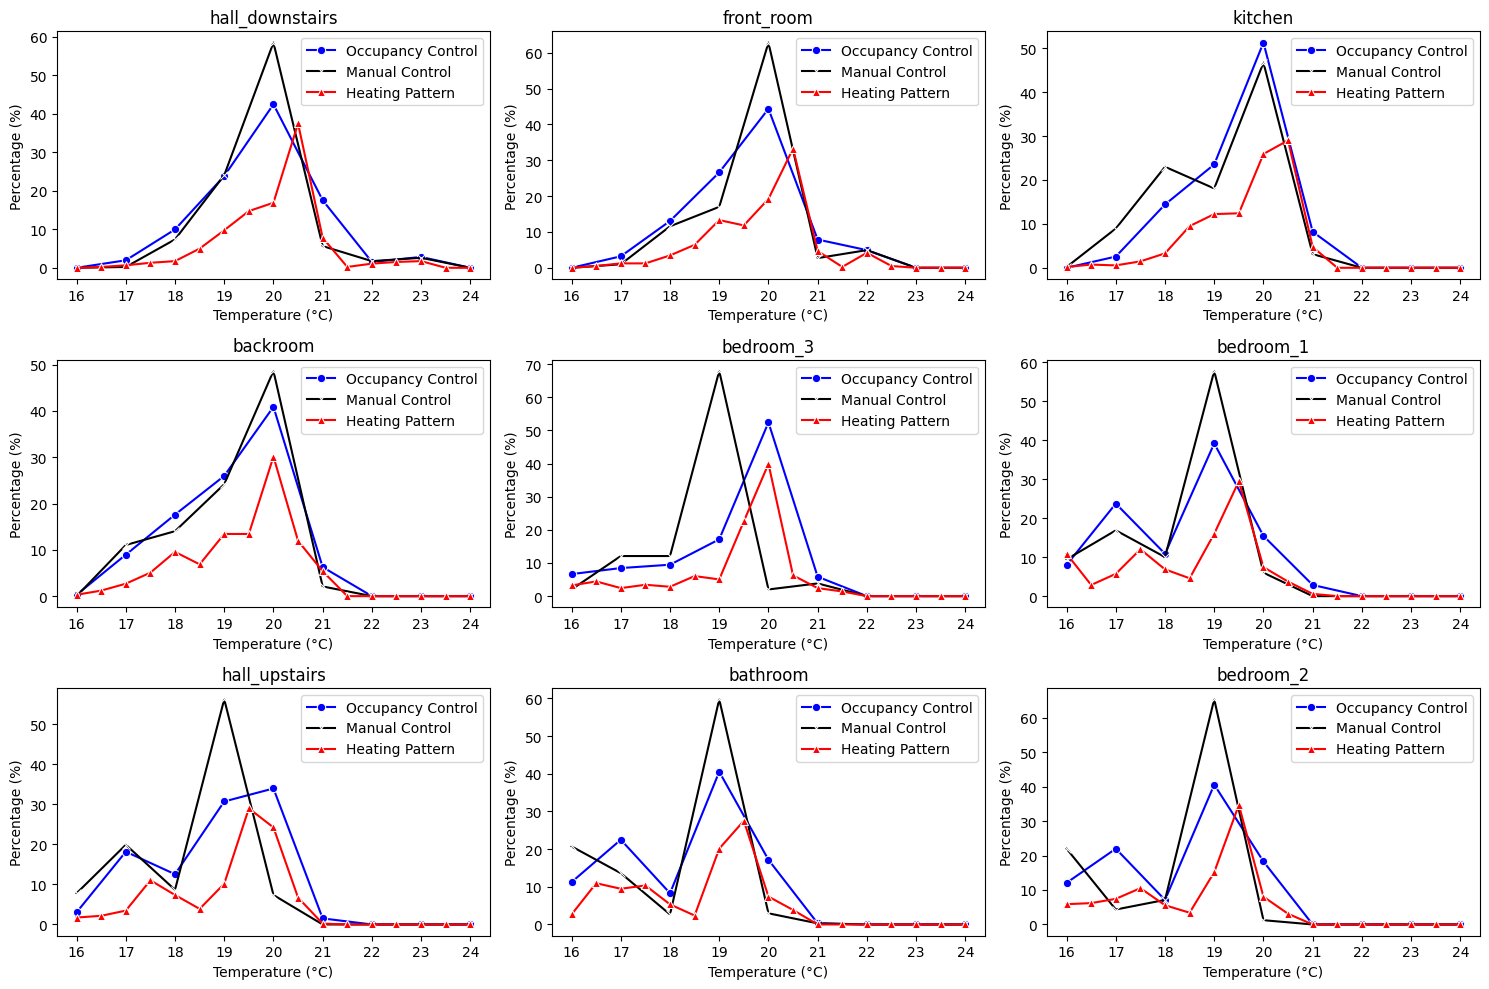

In [35]:
# Assuming df, df_0, and df_9 are your DataFrames containing the temperature distribution data
opr_temp_distributions_df = df['eval/opr_temperature_distribution']
opr_temp_distributions_df_0 = df_0['eval/opr_temperature_distribution']
opr_temp_distributions_df_9 = fd['eval/opr_temperature_distribution']

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
axes = axes.flatten()

# Loop over each room and plot the line plots from all three dataframes
for idx, (room, distribution) in enumerate(opr_temp_distributions_df.items()):
    # Convert the distribution dict of df to a DataFrame
    temp_df = pd.DataFrame(list(distribution.items()), columns=['Temperature', 'Percentage'])
    temp_df['Temperature'] = pd.to_numeric(temp_df['Temperature'])

    # Convert the distribution dict of df_0 to a DataFrame
    temp_df_0 = pd.DataFrame(list(opr_temp_distributions_df_0[room].items()), columns=['Temperature', 'Percentage'])
    temp_df_0['Temperature'] = pd.to_numeric(temp_df_0['Temperature'])

    # Convert the distribution dict of df_9 to a DataFrame
    temp_df_9 = pd.DataFrame(list(opr_temp_distributions_df_9[room].items()), columns=['Temperature', 'Percentage'])
    temp_df_9['Temperature'] = pd.to_numeric(temp_df_9['Temperature'])

    # Plot all three distributions as line plots on the same subplot
    sns.lineplot(x='Temperature', y='Percentage', data=temp_df, ax=axes[idx], color='b', label='Occupancy Control', marker='o')
    sns.lineplot(x='Temperature', y='Percentage', data=temp_df_0, ax=axes[idx], color='black', label='Manual Control', marker='x')
    sns.lineplot(x='Temperature', y='Percentage', data=temp_df_9, ax=axes[idx], color='r', label='Heating Pattern', marker='^')

    # Set the title for each subplot
    axes[idx].set_title(room)
    axes[idx].set_xlabel('Temperature (°C)')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend()

# Adjust the layout
plt.tight_layout()
plt.show()
